# Analyse exploratoire
## Introduction

Nous rappelons que le but de la mission est d'dentifier les causes d'attrition au sein de TechNova Partners.
La responsable SIRH a fourni 3 principaux fichiers source que nous allons analyser, et sur lesquels nous allons nous appuyer pour notre étude.

On peut les trouver dans `assets/` : 
* extrait_eval.csv
* extrait_sirh.csv
* extrait_sondage.csv

## Import des modules





In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Familiarisation avec les données

Dans un premier temps nous allons lire et tenter de comprendre chaque colonne de chaque extrait CSV. 

Nous nous attarderons plus tard sur le type de données pour chaque colonne ainsi que l'amplitude, les valeurs maximum (pour les notations par exemple), et la distribution

### Extrait SIRH
Le fichier est un extrait de la base de données du SIRH de TechNovaPartners. Il s'agit de la table principale des données anonymisées des employés de l'entreprise.

In [2]:
sirh = pd.read_csv("./assets/extrait_sirh.csv")
sirh.head()

,id_employee,age,genre,revenu_mensuel,statut_marital,departement,poste,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel
0,1,41,F,5993,Célibataire,Commercial,Cadre Commercial,8,80,8,6,4
1,2,49,M,5130,Marié(e),Consulting,Assistant de Direction,1,80,10,10,7
2,4,37,M,2090,Célibataire,Consulting,Consultant,6,80,7,0,0
3,5,33,F,2909,Marié(e),Consulting,Assistant de Direction,1,80,8,8,7
4,7,27,M,3468,Marié(e),Consulting,Consultant,9,80,6,2,2


Première analyse des colonnes :

 * `id_employee` : identifiant unique, peut servir à lier les tables entre elles
 * `age` : l'âge peut être intéressant pour dégager des tendances
 * `genre`
 * `revenu_mensuel`
 * `statut_marital`
 * `departement` : service dans lequel l'employé est affecté, donnée importante , peut permettre d'identifier des problèmes de process et/ou de management
 * `poste` : donnée importante qui peut permettre d'identifier des problèmes liés au poste, et/ou dont le poste peut être un facteur déterminant aux démissions
 * `nombre_experiences_precedentes`
 * `nombre_heures_travailless` : il semble que l'échantillon donné soit pour tous les individus de 80h travaillées, à analyser.
 * `annee_experience_totale`
 * `annees_dans_l_entreprise` : peut être déterminant, facteur de lassitude ou de besoin de nouvelles expériences
 * `annees_dans_le_poste_actuel` : également, facteur de lassitude, problématiques sur le poste

### Extrait Evaluation

Il s'agit d'un extrait de la base de données du SIRH de TechnovaPartners.
Plus particulièrement, il s'agit de la table qui recense les évaluations des employés.

In [3]:
evaluation = pd.read_csv("./assets/extrait_eval.csv")
evaluation.head()

,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,eval_number,note_evaluation_actuelle,heure_supplementaires,augementation_salaire_precedente
0,2,3,2,4,1,1,E_1,3,Oui,11 %
1,3,2,2,2,4,3,E_2,4,Non,23 %
2,4,2,1,3,2,3,E_4,3,Oui,15 %
3,4,3,1,3,3,3,E_5,3,Oui,11 %
4,1,3,1,2,4,3,E_7,3,Non,12 %


Première analyse des colonnes :

* `satisfaction_employee_environnement` : note de satisfaction pour l'employé de son environnement de travail
* `note_evaluation_precedente` : note de la précédente évaluation, permet de d'appréhender l'évolution du salarié
* `niveau_hierarchique_poste` : peut être intéressant pour détecter des problématiques de management (n+1 généralement), et/ou liées aux responsabilités du poste 
* `satisfaction_employee_nature_travail` : note de satisfaction pour l'employé de la nature de son travail
* `satisfaction_employee_equipe` : note de satisfaction pour l'employé de son équipe
* `satisfaction_employee_equilibre_pro_perso` : note de satisfaction pour l'employé de l'équilibre entre vie professionnelle et personnelle
* `eval_number` : semble être l'identifiant de l'évaluation 
* `note_evaluation_actuelle` : note actuelle
* `heure_supplementaires` : indique si l'employé a fait ou non des heures supplémentaires
* `augmentation_salaire_precedente` : pourcentage de la précédente augmentation de salaire, peut être utile pour comprendre l'évolution du salarié et ainsi le lier aux causes de départ éventuel

### Extrait Sondage

Il s'agit d'un extrait de la base de données du SIRH de TechnovaPartners.
Plus particulièrement, il s'agit de la table qui indique si l'employé a quitté l'entreprise et qui recense plus d'informations sur son environnement et ses conditions de travail


In [4]:
sondage = pd.read_csv("./assets/extrait_sondage.csv")
sondage.head()

,a_quitte_l_entreprise,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,code_sondage,distance_domicile_travail,niveau_education,domaine_etude,ayant_enfants,frequence_deplacement,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
0,Oui,0,0,1,1,1,2,Infra & Cloud,Y,Occasionnel,0,5
1,Non,1,3,1,2,8,1,Infra & Cloud,Y,Frequent,1,7
2,Oui,0,3,1,4,2,2,Autre,Y,Occasionnel,0,0
3,Non,0,3,1,5,3,4,Infra & Cloud,Y,Frequent,3,0
4,Non,1,3,1,7,2,1,Transformation Digitale,Y,Occasionnel,2,2


Première analyse des colonnes :

* `a_quitte_l_entreprise` : information cruciale pour notre analyse, on a besoin de savoir si le salarié a quitté ou pas l'entreprise pour en déterminer les causes
* `nombre_participation_pee` : permet de savoir si le salarié a particié au PEE (actionariat salarié), donne un niveau d'implication indirecte du salarié qui peut permettre de donner des tendances (attention peut dépendre aussi des moyens du salarié, ce n'est pas égal à l'implication réelle du salarié)
* `nb_formations_suivies` : peut être un indicateur d'investissement de l'entreprise envers un salarié
* `nombre_employee_sous_responsabilité` : indicateur quantitatif du niveau de responsabilité
* `code_sondage` : certainement l'identifiant du sondage associé
* `distance_domicile_travail` : semble être en kms (1 à 29). Indicateur de la distance qui peut influencer la pénibilité pour rejoindre le lieu de travail
* `niveau_education` : peut être un bon indicateur pour permettre de voir quels types de profils l'entreprise parvient à garder ou non, en fonction de son niveau d'éducation (semble être bac + x années d'études, sinon simple quantitatif)
* `domaine_etude` : idem peut permettre de dégager des tendances selon le profil,.
* `ayant_enfants` : à vérifier au cours de l'analyse, il semble que pour tout l'échantillon la réponse soit "Y" (oui)
* `frequence_deplacement` : variable de classification ordinale, plus les déplacements sont fréquents plus cela peut impacter la pénibilité au travail
* `annees_depuis_la_derniere_promotion` : indicateur important qui peut être lié à une problématique de reconnaissance du travail, et/ou de performance du salarié
* `annes_sous_responsable_actuel` : indicateur intéressant qui peut permettre de dégager des tendances en fonction du manager, et déceler des problématiques de management (ou lassitude).

### Bilan de la familiarisation

On constate qu'on a plusieurs données intéressantes pour notre analyse. Beaucoup de facteurs peuvent influencer le salarié pour mener à sa démission.
Il nous faut désormais approfondir l'étude : 

* pour mieux comprendre les valeurs des variables (unités, amplitude, type de variable, distributions)
* pour permettre de lier les 3 extraits entre eux : les tables extrait_eval et extrait_sondage n'ont pas de clé étrangère faisant le lien explicite vers extrait_sirh. Pareil dans l'autre sens.
  * Sans information complémentaire on pourra considérer que la ligne n d'un fichier correspond à la ligne n des autres fichiers, il conviendra bien sûr de vérifier cette hypothèse (comparaison du nombre de lignes, de la cohérence des données, etc.)
* pour nettoyer les données avant la création d'un modèle ML

## Rapprochement des fichiers de données

### Mise en exergue des identifiants d'employés

Actuellement les données sont séparées dans 3 fichiers différents. Nous n'avons pas encore trouvé de discriminant significatif (clé étrangère) pour les lier entre eux.
En analysant de nouveau chacun des fichiers on se rend compte que : 

* **chaque fichier a exactement 1470 lignes** (même cardinalité)
* le champ `id_employee` contient des valeurs entières discrètes, et qui ne se suivent pas nécessairement (par exemple on passe de l'id 5 à l'id 7)
* pour l'extrait evaluation, le champ `eval_number` semble être de la forme "E_[id_employee]", il suit la même numérotation dans l'ordre des lignes que `id_employee`
* pour l'extrait sondage, le champ `code_sondage` suit la même numérotation dans l'ordre des lignes que `id_employee`

Pour vérifier notre hypothèse on s'assure que les valeurs des champs `id_employee`, `eval_number` et `code_sondage` sont identiques ligne par ligne.
C'est-à-dire que pour chaque ligne de chaque fichier on vérifie la correspondance **exacte** des valeurs entières dans ces champs.

**Remarque : Le fait que les valeurs dans `id_employee` ne se suivent pas exactement nous aident à déduire que les valeurs des champs liés ne sont pas simplement itérés de 1 à chaque ligne, mais correspondent bien à l'id, puisqu'elles aussi sont itérées de la même manière**

In [5]:
# Extraire les ID de eval_number (E_X -> X)
evaluation['id'] = evaluation['eval_number'].str[2:].astype(int)

# Vérifier si toutes les lignes correspondent
match = (sirh['id_employee'] == evaluation['id']).all() and (sirh['id_employee'] == sondage['code_sondage']).all()

print(f"✅ Correspondance parfaite: {match}")
print(f"Lignes: {len(sirh)} = {len(evaluation)} = {len(sondage)}")

✅ Correspondance parfaite: True
Lignes: 1470 = 1470 = 1470


**La correspondance est parfaite sur les 1470 lignes**

### Vérification de la cohérence après rapprochement des lignes

On sait maintenant que : 

* chaque ligne des 3 fichiers sont triées dans l'ordre
* les champs `id_employee`, `eval_number`et `code_sondage` semblent représenter la même chose (identifiant unique de l'employé)
* ces 3 champs ligne par ligne ont exactement la même valeur entière discrète (après retrait du préfixe "E_" pour `eval_number`) pour l'ensemble de l'échantillon

Toutefois, cela ne peut pas prouver complètement que chaque ligne des 3 fichiers sont liées une par une. Même si le risque est faible, il pourrait y avoir une coïncidence algorithmique dans la génération de ces valeurs à la création des fichiers ou des données.

**Pour plus de certitude, on va donc faire quelques vérifications de cohérence entres les différentes variables ligne par ligne sur les 3 fichiers.**




In [6]:
print("=== TESTS DE COHÉRENCE SÉMANTIQUE ===")

# Test 1: SIRH ↔ EVAL - Revenu vs Niveau hiérarchique (corrélation de Pearson)
corr1 = sirh['revenu_mensuel'].corr(evaluation['niveau_hierarchique_poste'])
print(f"Corrélation Revenu ↔ Niveau hiérarchique: {corr1:.3f}")

# Test 2: SIRH ↔ SONDAGE - Ancienneté entreprise vs Années sous responsable actuel (corrélation de Pearson)
corr2 = sirh['annees_dans_l_entreprise'].corr(sondage['annes_sous_responsable_actuel'])
print(f"Corrélation Ancienneté entreprise ↔ Années sous responsable: {corr2:.3f}")

print(f"\n✅ Corrélations > 0.5 = cohérence sémantique forte ~= même employé")
print(f"\n✅ Corrélations > 0.3 = cohérence sémantique modérée ~= même employé")
print(f"❌ Corrélations ~0 = alignement algorithmique suspect")

=== TESTS DE COHÉRENCE SÉMANTIQUE ===
Corrélation Revenu ↔ Niveau hiérarchique: 0.950
Corrélation Ancienneté entreprise ↔ Années sous responsable: 0.769

✅ Corrélations > 0.5 = cohérence sémantique forte ~= même employé

✅ Corrélations > 0.3 = cohérence sémantique modérée ~= même employé
❌ Corrélations ~0 = alignement algorithmique suspect


**Bilan : Les tests de cohérence montrent des corrélations fortes, on peut considérer que notre hypothèse est validée**

### Création du dataframe unifié

In [7]:
# Extraire l'ID de eval_number pour la jointure
evaluation['id_employee'] = evaluation['eval_number'].str[2:].astype(int)

# Joindre les 3 dataframes sur id_employee
sirh_unifie = sirh.merge(evaluation, on='id_employee', how='inner')
sirh_unifie = sirh_unifie.merge(sondage, left_on='id_employee', right_on='code_sondage', how='inner')

# Supprimer les colonnes redondantes
sirh_unifie = sirh_unifie.drop(['eval_number', 'code_sondage'], axis=1)

# Sauvegarder le dataframe unifié
sirh_unifie.to_csv('./assets/sirh_unifie.csv', index=False, sep=',', encoding='utf-8')

## Nettoyage des données

Dans cette étape nous allons vérifier la cohérence des données, les valeurs manquantes et aberrantes. 

### Valeurs manquantes

In [8]:
df = pd.read_csv("./assets/sirh_unifie.csv")

# Recherche des valeurs manquantes
print(df.isnull().sum())

id_employee                                  0
age                                          0
genre                                        0
revenu_mensuel                               0
statut_marital                               0
departement                                  0
poste                                        0
nombre_experiences_precedentes               0
nombre_heures_travailless                    0
annee_experience_totale                      0
annees_dans_l_entreprise                     0
annees_dans_le_poste_actuel                  0
satisfaction_employee_environnement          0
note_evaluation_precedente                   0
niveau_hierarchique_poste                    0
satisfaction_employee_nature_travail         0
satisfaction_employee_equipe                 0
satisfaction_employee_equilibre_pro_perso    0
note_evaluation_actuelle                     0
heure_supplementaires                        0
augementation_salaire_precedente             0
id           

* **Il n'y a aucune valeur manquante**

### Doublons

In [9]:
# Recherche des doublons
df.duplicated().sum()

np.int64(0)

* **Il n'y a aucun doublon de données**

### Valeurs aberrantes / outliers

In [10]:
pd.set_option('display.max_columns', None)
df.describe().round(2)

,id_employee,age,revenu_mensuel,nombre_experiences_precedentes,nombre_heures_travailless,annee_experience_totale,annees_dans_l_entreprise,annees_dans_le_poste_actuel,satisfaction_employee_environnement,note_evaluation_precedente,niveau_hierarchique_poste,satisfaction_employee_nature_travail,satisfaction_employee_equipe,satisfaction_employee_equilibre_pro_perso,note_evaluation_actuelle,id,nombre_participation_pee,nb_formations_suivies,nombre_employee_sous_responsabilite,distance_domicile_travail,niveau_education,annees_depuis_la_derniere_promotion,annes_sous_responsable_actuel
count,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.00,1470.0,1470.00,1470.00,1470.00,1470.00
mean,1024.87,36.92,6502.93,2.69,80.0,11.28,7.01,4.23,2.72,2.73,2.06,2.73,2.71,2.76,3.15,1024.87,0.79,2.80,1.0,9.19,2.91,2.19,4.12
std,602.02,9.14,4707.96,2.50,0.0,7.78,6.13,3.62,1.09,0.71,1.11,1.10,1.08,0.71,0.36,602.02,0.85,1.29,0.0,8.11,1.02,3.22,3.57
min,1.00,18.00,1009.00,0.00,80.0,0.00,0.00,0.00,1.00,1.00,1.00,1.00,1.00,1.00,3.00,1.00,0.00,0.00,1.0,1.00,1.00,0.00,0.00
25%,491.25,30.00,2911.00,1.00,80.0,6.00,3.00,2.00,2.00,2.00,1.00,2.00,2.00,2.00,3.00,491.25,0.00,2.00,1.0,2.00,2.00,0.00,2.00
50%,1020.50,36.00,4919.00,2.00,80.0,10.00,5.00,3.00,3.00,3.00,2.00,3.00,3.00,3.00,3.00,1020.50,1.00,3.00,1.0,7.00,3.00,1.00,3.00
75%,1555.75,43.00,8379.00,4.00,80.0,15.00,9.00,7.00,4.00,3.00,3.00,4.00,4.00,3.00,3.00,1555.75,1.00,3.00,1.0,14.00,4.00,3.00,7.00
max,2068.00,60.00,19999.00,9.00,80.0,40.00,40.00,18.00,4.00,4.00,5.00,4.00,4.00,4.00,4.00,2068.00,3.00,6.00,1.0,29.00,5.00,15.00,17.00


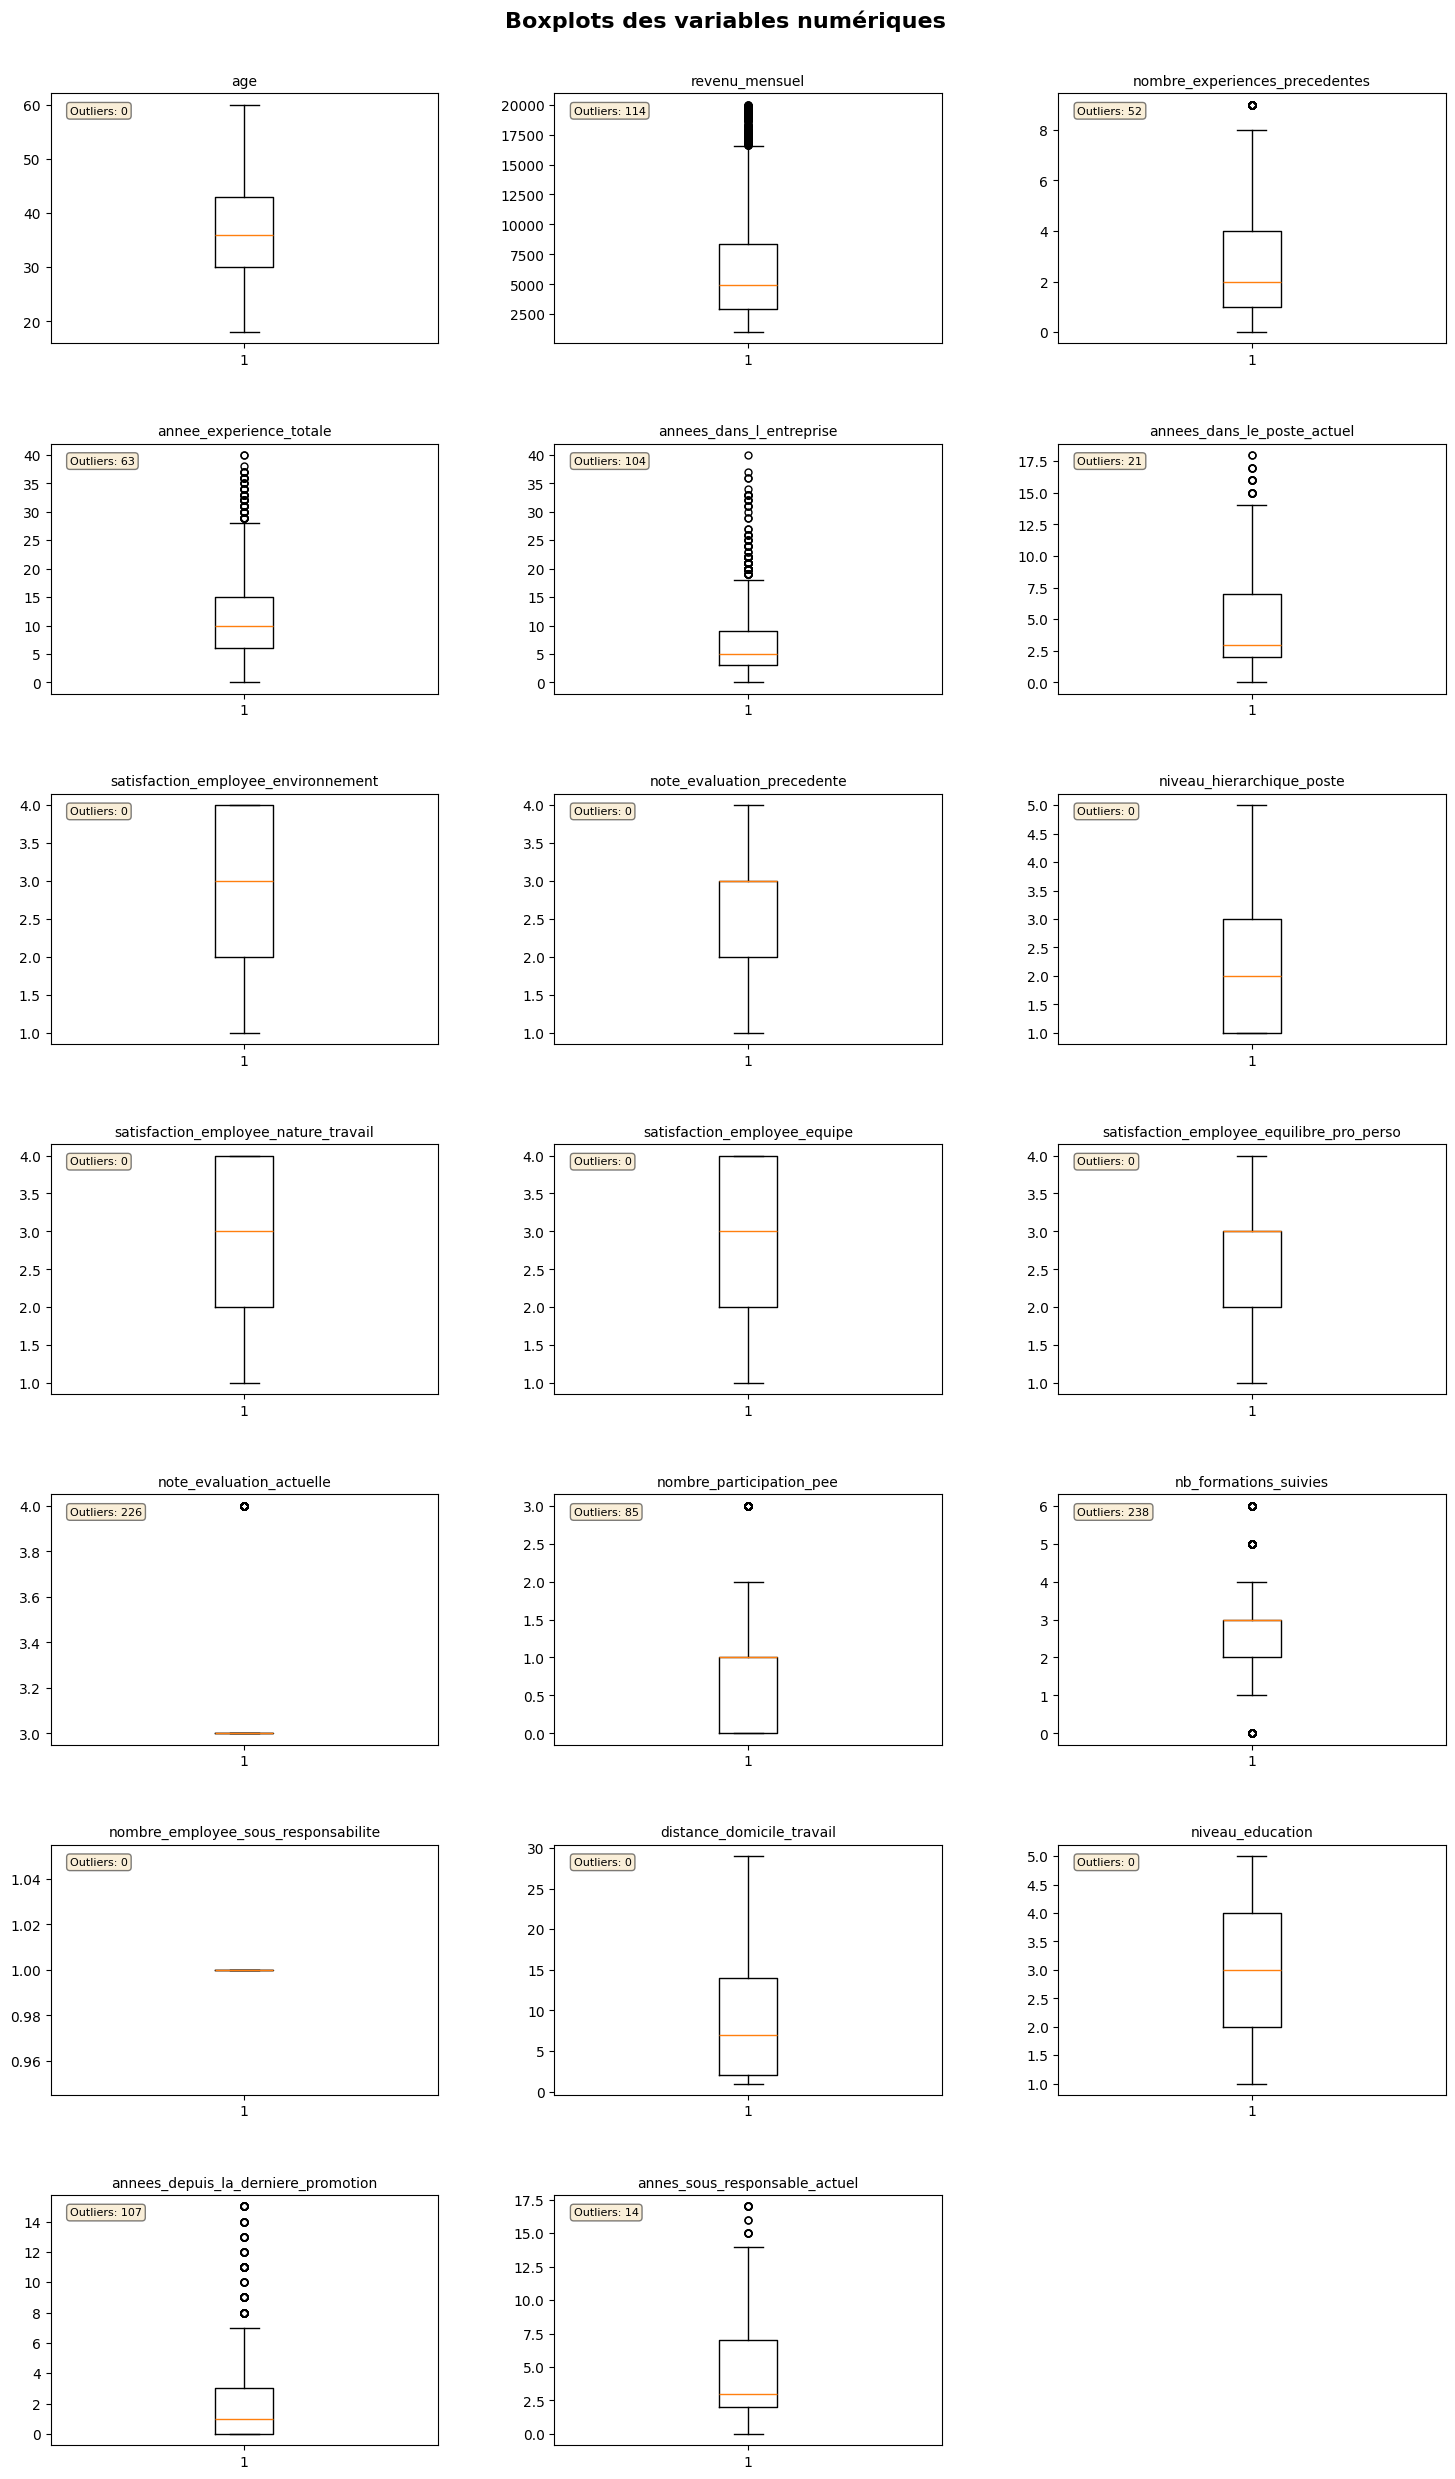

In [11]:
import matplotlib.pyplot as plt

# Colonnes numériques sauf quelques-unes
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()
exclude_cols = ['id_employee', 'nombre_heures_travailless', 'id']
numeric_cols = [col for col in numeric_cols if col not in exclude_cols]

# Nombre de subplots
n = len(numeric_cols)
rows = (n // 3) + (1 if n % 3 else 0)
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(18, rows*4))
fig.suptitle("Boxplots des variables numériques", fontsize=16, weight="bold")

axes = axes.flatten()

for i, var in enumerate(numeric_cols):
    # Boxplot
    axes[i].boxplot(df[var].dropna(), flierprops=dict(marker='o', color='red', markersize=5))
    axes[i].set_title(var, fontsize=10)

    # Calcul IQR
    Q1 = df[var].quantile(0.25)
    Q3 = df[var].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR
    outliers_count = len(df[(df[var] < lower) | (df[var] > upper)])

    # Ajouter un petit encadré "Outliers: X"
    axes[i].text(
        0.05, 0.95, f'Outliers: {outliers_count}',
        transform=axes[i].transAxes,
        fontsize=8, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5)
    )

# Supprimer axes vides
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.subplots_adjust(top=0.95, hspace=0.4, wspace=0.3)
plt.show()

#### Conclusions
**Outliers détectés** : 
* revenu_mensuel: 114 (7.8%)
* annee_experience_totale: 63 (4.3%)
* annees_dans_l_entreprise: 104 (7.1%)
* annees_dans_le_poste_actuel: 21 (1.4%)
* note_evaluation_actuelle: 226 (15.4%)
* annees_depuis_la_derniere_promotion: 107 (7.3%)

**Principaux outliers** : 
* Revenus très élevés (Senior Managers, Directeurs)
* Expérience/ancienneté élevée (employés seniors)
* Notes d'évaluation 4/4 (15% des employés)
* Promotions tardives (> 7 ans)

**Cohérence logique: Aucune incohérence majeure détectée**. Ces valeurs semblent cohérentes avec la réalité RH (hiérarchie, séniorité).
